## **Evaluation Chart**



Upload `performance_average.csv` before running the visualization cells.

In [ ]:
from google.colab import files

uploaded = files.upload()

import pandas as pd

df_average = pd.read_csv("performance_average.csv")

df_average.head()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json

from collections import Counter

In [ ]:
df_combined = df_average.copy()

In [ ]:
method_order = [
    "Pandas Optimization",
    "Polars Optimization",
    "DuckDB Optimization"
]

df_combined["Optimization Stage"] = pd.Categorical(
    df_combined["Optimization Stage"],
    categories=method_order,
    ordered=True
)

df_combined

,Optimization Stage,Total Jobs,Total Full Time Jobs,Total Contract Jobs,Salary Disclosed Jobs,Expiring Jobs,Average Days Ago,Most Common Country,Most Common Industry,Total Processing Time (seconds),CPU Usage (%),Memory Usage (MB),Throughput (records/second)
0,Pandas Optimization,113007.0,101609.0,9444.0,48869.0,14831.0,14.48,Malaysia,Unknown,0.73,49.91,529.61,155543.49
1,Polars Optimization,113007.0,101609.0,9444.0,48869.0,14831.0,14.48,Malaysia,Unknown,0.17,94.07,524.53,675684.53
2,DuckDB Optimization,113007.0,101609.0,9444.0,48869.0,14831.0,14.48,Malaysia,Unknown,0.28,59.42,499.47,415735.55


In [ ]:
sns.set(
    style="darkgrid",
    context="notebook"
)

colors = sns.color_palette(
    "viridis",
    len(method_order)
)

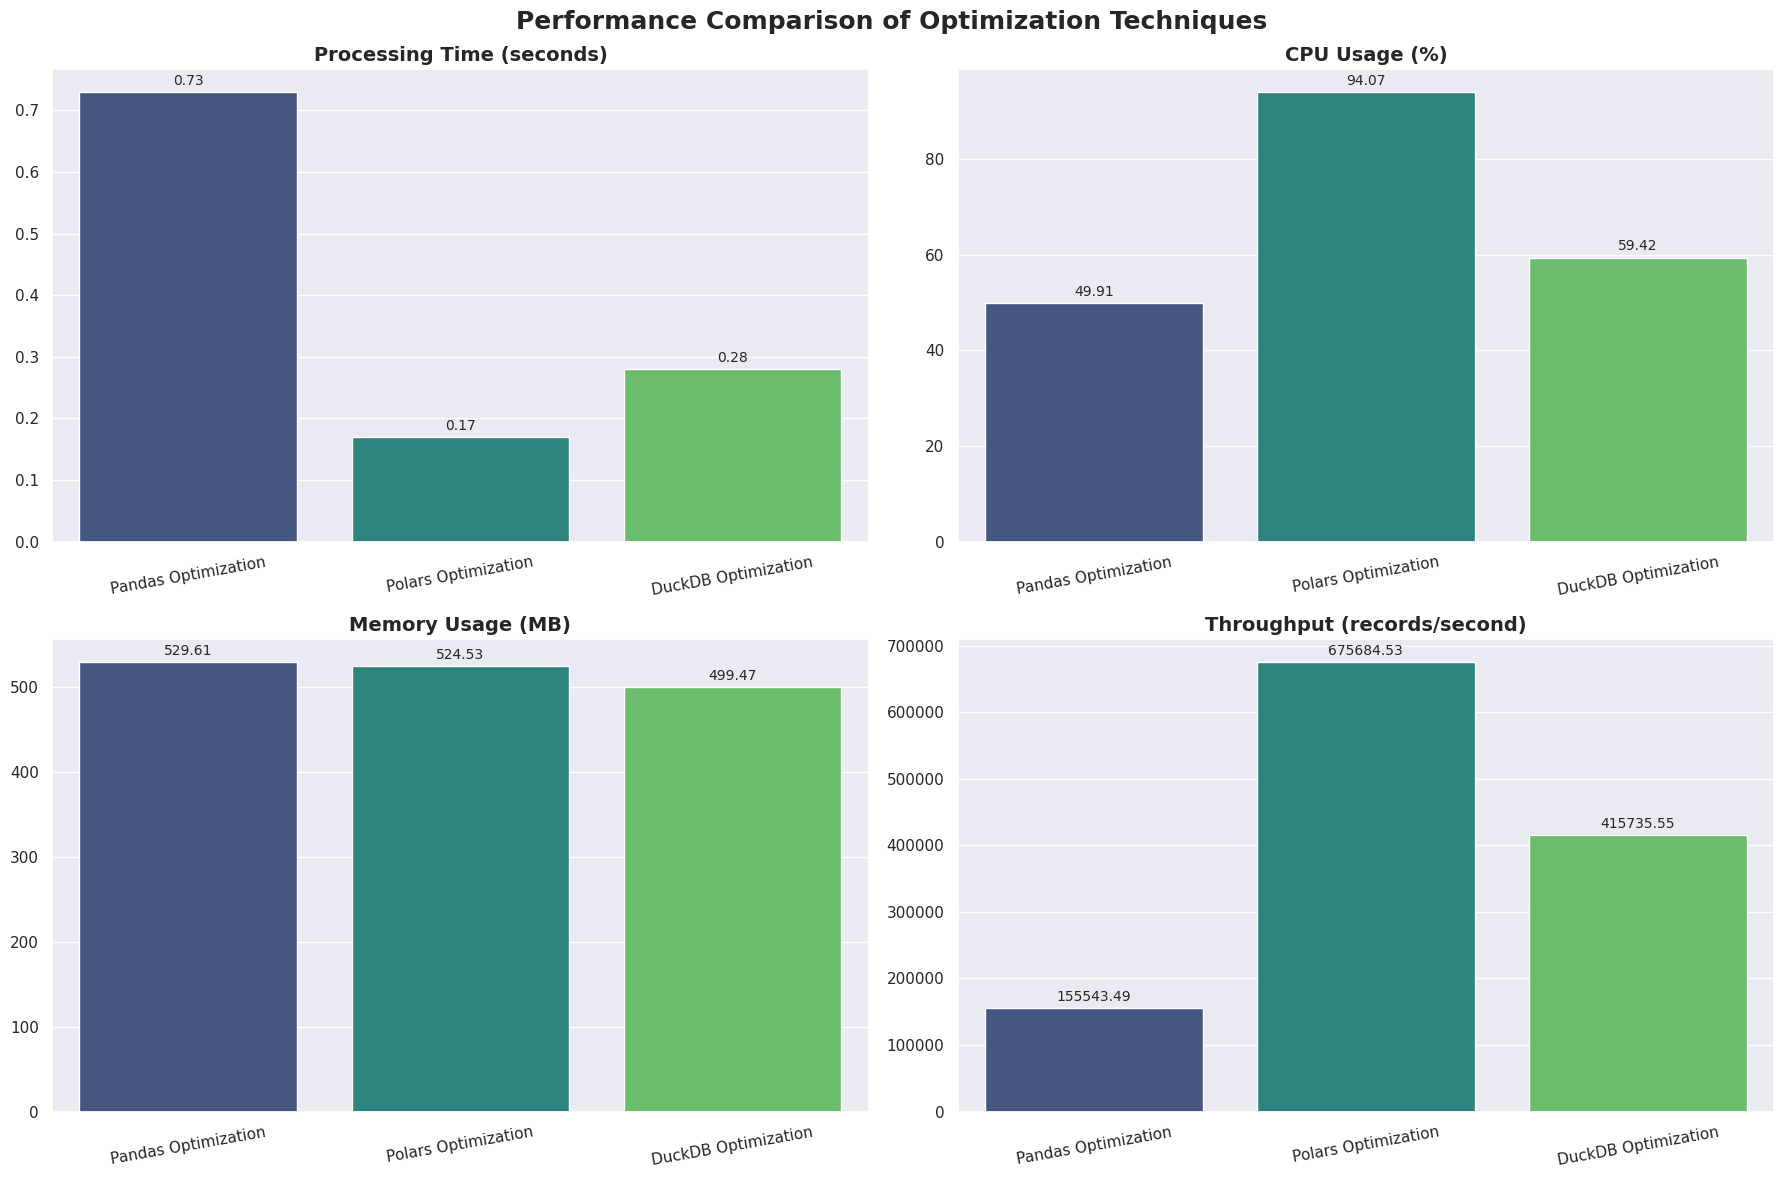

In [ ]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12)
)

axes = axes.flatten()

best_optimization = {}

for i, (column, (title, preference)) in enumerate(metrics.items()):

    ax = axes[i]

    sns.barplot(
        data=df_combined,
        x="Optimization Stage",
        y=column,
        hue="Optimization Stage",
        palette=colors,
        ax=ax,
        legend=False
    )

    # Add labels on bars
    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=10
        )

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(
        axis='x',
        rotation=10
    )

    # Determine best optimization
    grouped = df_combined.groupby(
        "Optimization Stage",
        observed=False
    )[column].mean()

    if preference == "lower is better":

        best_method = grouped.idxmin()

    else:

        best_method = grouped.idxmax()

    best_optimization[title] = best_method

# Main title
fig.suptitle(
    "Performance Comparison of Optimization Techniques",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

In [ ]:
overall_best = Counter(
    best_optimization.values()
).most_common(1)[0][0]

print("\n--- Overall Recommended Optimization Technique ---")

print(
    f"The overall best optimization method is: {overall_best}"
)


--- Overall Recommended Optimization Technique ---
The overall best optimization method is: Polars Optimization
